In [1]:
import os 
os.environ['CUDA_VISIBLE_DEVICES']="1,2"

In [2]:
import torch 
import torch.nn as nn
import torch.nn.functional as F

import os

from tqdm import tqdm
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader

from CityScapes.datasets.progan_dataset import ProGanCityscapesDataset
from file_management import get_version_folder, save_config, load_config
from progan_model import Generator, Discriminator, gradient_penalty

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [36]:
root = 'cache/progan'
index_folder = get_version_folder(root)
config = load_config('pro-gan.yaml')
config['root_path'] =index_folder

config_target_path = os.path.join(index_folder,'config.yaml')
save_config(config, config_target_path)



Config saved to cache/progan/13/config.yaml


In [4]:

channels = config['channels']
# channels = [16] * len(channels)
sizes = [4 *(2**i) for i in range(len(channels))]
z_dim  = config['z_dim']
img_channels =3
batch_sizes = config['batch_sizes']
# assert len(batch_sizes) == len(sizes)

epochs = config['epochs']

disc_lr= config['disc_lr']
gen_lr= config['gen_lr']
LAMBDA_GP  =config['LAMBDA_GP']
critic_mean_penalty = config['critic_mean_penalty']
alpha_start = config['alpha_start']

In [5]:



datasets = [ProGanCityscapesDataset(size=s) for s in sizes]
dataloaders = [DataLoader(d, batch_size=b_size, shuffle=True) for d,b_size in zip(datasets,batch_sizes)]


gen = Generator(z_dim =z_dim,
                channels=channels,
                img_channels=img_channels).to(device)

disc = Discriminator(channels=channels,
                    img_channels=img_channels).to(device)

disc_optimizer = torch.optim.Adam(disc.parameters(), lr=disc_lr,betas=(0.0,0.99))
gen_optimizer = torch.optim.Adam(gen.parameters(), lr=gen_lr,betas=(0.0,0.99))

In [39]:
start_step =5

for step in range(start_step,len(sizes)):
    step_path = os.path.join(config["root_path"],str(step))
    generated_images_path = os.path.join(step_path,'generated_images')
    os.makedirs(step_path, exist_ok=True)
    os.makedirs(generated_images_path, exist_ok=True)
    loader =dataloaders[step]
    alpha =  alpha_start
    for epoch in range(epochs):
        loop = tqdm(loader, desc=f"Epoch {epoch+1}/{epochs}, size={sizes[step]}")

        for batch_idx, real in enumerate(loop):
            real = real.to(device)
            cur_batch_size = real.shape[0]
            noise = torch.randn(cur_batch_size, z_dim, 1, 1).to(device)

            # train discriminator
            disc_optimizer.zero_grad()

            fake = gen(noise, alpha, step)
            disc_real = disc(real, alpha, step)
            disc_fake = disc(fake.detach(), alpha, step)
            gp = gradient_penalty(disc, real, fake, alpha, step, device=device)
            loss_disc = (
                -(torch.mean(disc_real) - torch.mean(disc_fake))
                + LAMBDA_GP * gp
                + (critic_mean_penalty * torch.mean(disc_real ** 2))
            )
        
            loss_disc.backward()
            disc_optimizer.step()


            # train generator
            gen_optimizer.zero_grad()
            # fake = gen(noise, alpha, step)
            gen_fake = disc(fake, alpha, step)
            loss_gen = -torch.mean(gen_fake)
            loss_gen.backward()
            gen_optimizer.step()


            alpha = alpha + 2/(len(loader)*epochs)
            alpha = min(alpha, 1)

        
            loop.set_postfix(loss_gen=loss_gen.item(), loss_disc=loss_disc.item(),alpha=alpha)

        cur_batch_size  = 2
        noise = torch.randn(cur_batch_size, z_dim, 1, 1).to(device)

        fake = gen(noise, 1,step)
        fig,ax = plt.subplots(1,cur_batch_size)
        for i in range(cur_batch_size):
            ax[i].imshow((fake[i].detach().cpu().permute(1,2,0)+1)/2)

        plt.savefig(os.path.join(generated_images_path,f"fake_{epoch}.png"))

        torch.save(gen.state_dict(), os.path.join(step_path,f"gen.pt"))
        torch.save(disc.state_dict(), os.path.join(step_path,f"disc.pt"))


Epoch 1/20, size=128:   2%|▏         | 39/2500 [00:07<07:54,  5.18it/s, alpha=0.00157, loss_disc=-8.07, loss_gen=16.9]


KeyboardInterrupt: 

In [40]:
gen.load_state_dict(torch.load('cache/progan/11/gen.pth_6.pt'))
disc.load_state_dict(torch.load('cache/progan/11/disc.pth_6.pt'))

<All keys matched successfully>

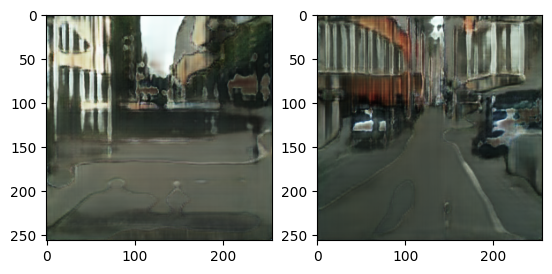

In [34]:
import matplotlib.pyplot as plt

step =6
data = next(iter(dataloaders[step]))
cur_batch_size  = 2
noise = torch.randn(cur_batch_size, z_dim, 1, 1).to(device)

# # step = 4

fake = gen(noise, 1,step)
batch_size = fake.shape[0]
fig,ax = plt.subplots(1,batch_size)
for i in range(batch_size):
    ax[i].imshow((fake[i].detach().cpu().permute(1,2,0)+1)/2)

